In [55]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *
from joblib import Parallel, delayed
from matplotlib.pyplot import imshow
import warnings
warnings.filterwarnings("ignore")
from scipy.optimize import curve_fit


In [2]:
def compute_P_for_g(g, U):
    print(g / gs[-1])
    return np.array([kb.P_n(ni, U, k) for ni in ns])

# compute dat for a single U
def compute_dat_for_U(U):
    return array([kb.PZ_n(ni, U, k) for ni in ns])



The object of this notebook is to analyze $P^z_n$ against g and n. 

I know that at criticality it has that log form that I wrote to souvik. What about as it goes away from criticality? 

In [157]:
#Constants
L = 100
k = kb.k_vals(L)
ns = np.arange(1,14)
#Points both near and far from criticality
gs = np.linspace(0,1,5)


In [158]:
Us = [kb.U(k,gi) for gi in gs]
# parallelize over Us
dat_all = Parallel(n_jobs=-1)(
    delayed(compute_dat_for_U)(U) for U in Us
)


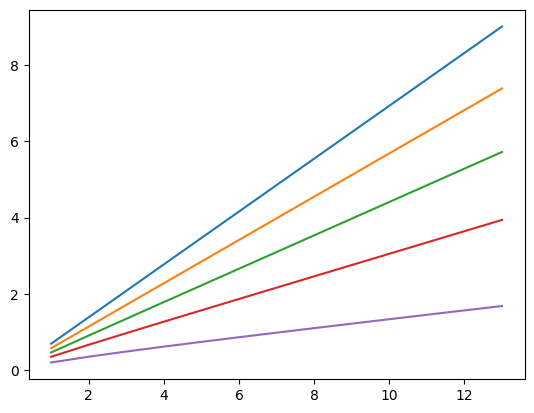

In [159]:
# example plot: all curves overlaid
for dat,g in zip(dat_all,gs):
    plot(ns, -np.log(dat),label=g)


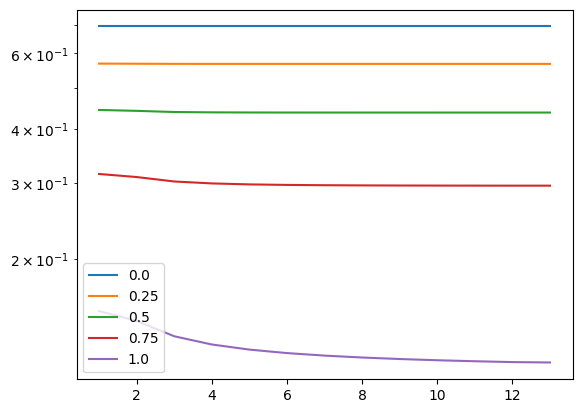

In [161]:
# example plot: all curves overlaid
for dat,g in zip(dat_all,gs):
    plot(ns, np.gradient(-np.log(dat),ns),label=g)
yscale("log")
legend()

Text(0.5, 1.0, '$-\\log(P^z_n)$')

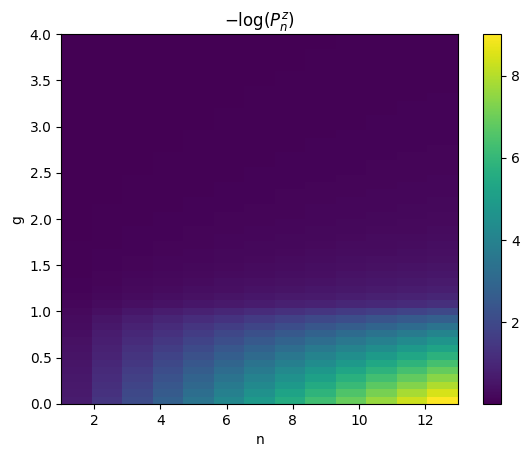

In [136]:
imshow(-np.real(np.log(dat_all)),origin="lower",extent=[ns[0],ns[-1],gs[0],gs[-1]],aspect="auto")
xlabel("n")
ylabel("g")
plt.colorbar()
title(r"$-\log(P^z_n)$")

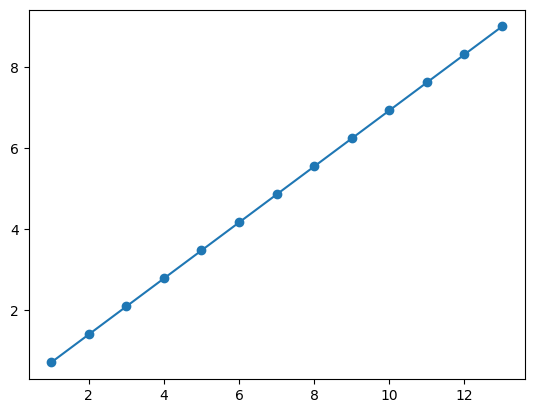

In [85]:
def ansatz(n,a0,a1,a2,b0,b1):
    return a0+n*a1+n*n*a2+b0*log(n)+b1*log(n)*n

test_dat = -log(dat_all[0])
p0 = (0, 0, 0, 0, 0)          # initial guess for (a0,a1,a2,b0,b1)
popt, pcov = curve_fit(ansatz, ns, test_dat, p0=p0)

a0, a1, a2, b0, b1 = popt    # fitted parameters
plot(ns,test_dat)
scatter(ns,ansatz(ns,*popt))


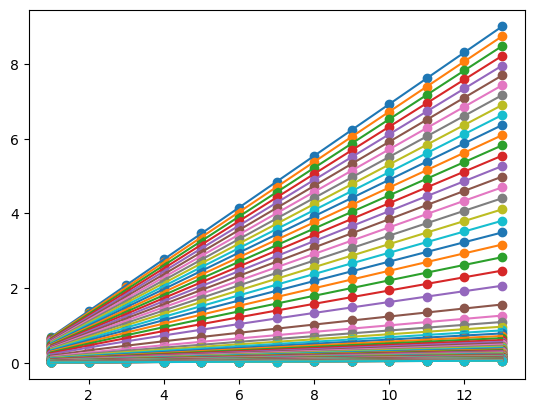

In [86]:
a0s =[]
a1s =[]
a2s =[]
b0s  = []
b1s = []
for dat in dat_all:
    p0 = (0, 0, 0, 0, 0)          # initial guess for (a0,a1,a2,b0,b1)
    popt, pcov = curve_fit(ansatz, ns, -log(dat), p0=p0)

    a0, a1, a2, b0, b1 = popt    # fitted parameters
    a0s.append(a0)
    a1s.append(a1)
    a2s.append(a2)
    b0s.append(b0)
    b1s.append(b1)
    scatter(ns,ansatz(ns,*popt))
    plot(ns,-log(dat))


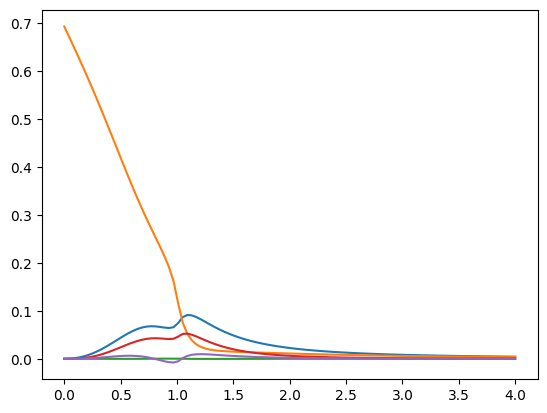

In [87]:
plot(gs,a0s)
plot(gs,a1s)
plot(gs,a2s)
plot(gs,b0s)
plot(gs,b1s)

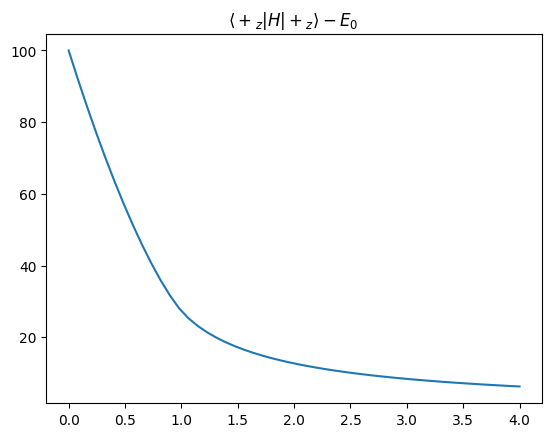

In [139]:
dat=[]
for g in gs:
    E =-g*L+sum(kb.epsilon(k,g))/2
    dat.append(E)#/min(kb.epsilon(k,g)))
title(r"$\langle +_z| H | +_z \rangle -E_0$ ")
plot(gs,dat)
#loglog()

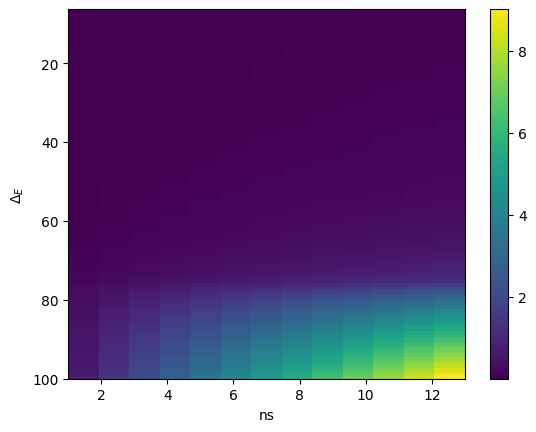

In [108]:
imshow(-np.real(np.log(dat_all)),origin="lower",extent=[ns[0],ns[-1],dat[0],dat[-1]],aspect="auto")
xlabel("ns")
ylabel(r"$\Delta_E$")
plt.colorbar()

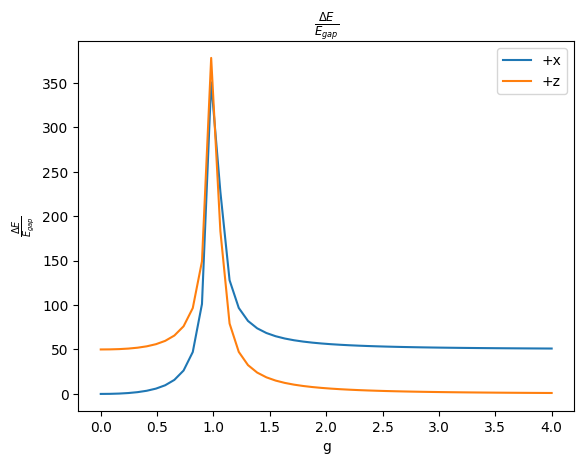

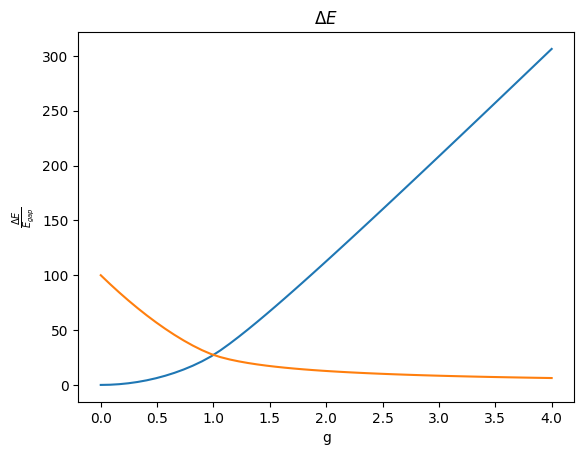

In [151]:
dat=[]
for g in gs:
    E =-L+sum(kb.epsilon(k,g))/2
    dat.append(E/min(kb.epsilon(k,g)))
#title(r"$\langle +_x| H | +_x \rangle -E_0$ ")
plot(gs,dat,label="+x")
xlabel("g")
ylabel(r"$\frac{\Delta E}{E_{gap}}$")
title(r"$\frac{\Delta E}{E_{gap}}$")

#loglog()

dat=[]
for g in gs:
    E =-g*L+sum(kb.epsilon(k,g))/2
    dat.append(E/min(kb.epsilon(k,g)))
#title(r"$\langle +_z| H | +_z \rangle -E_0$ ")
plot(gs,dat,label="+z")
legend()
show()

###############################
#loglog()
dat=[]
for g in gs:
    E =-L+sum(kb.epsilon(k,g))/2
    dat.append(E)
plot(gs,dat)
xlabel("g")
ylabel(r"$\frac{\Delta E}{E_{gap}}$")
title(r"$\Delta E$")
dat=[]
for g in gs:
    E =-g*L+sum(kb.epsilon(k,g))/2
    dat.append(E)
plot(gs,dat)
show()
#loglog()

